# **밀도기반 군집화 (Density-based clustering)**
### **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**
- **데이터 포인트의 밀도를 기준으로 클러스터를 형성하며, 밀도가 낮은 영역에 위치한 데이터 포인트는 noise로 간주**
- **복잡한 형태의 클러스터와 noise가 많은 데이터셋에서 효과적이며 이상탐지에 활용**

# **2.실습**

## **2-1.필요한 라이브러리 임포트**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 정규화 패키지
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 군집분석 관련 패키지
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# 차원축소를 위한 패키지
from sklearn.decomposition import PCA

## **2-2. 데이터셋 설명 (Credit Card Fraud Detection)**
- **Time: 첫 거래와의 경과 시간 (초 단위)**
- **Amount: 거래 금액**
- **X 변수: 거래 특성으로 민감 정보 보호를 위해 암호화**
- **Y 변수: 거래유형 (2개 클래스 :  0 = 정상 거래, 1 = 사기 거래)**

## **2-3.데이터 로드 및 전처리**

In [2]:
# 신용카드 데이터셋 로드
credit_df = pd.read_csv("../Data/creditcard.csv")
credit_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127373,78308,1.256197,0.382598,0.314188,0.689831,-0.336645,-1.063868,0.113954,-0.226451,-0.027626,...,-0.282913,-0.797489,0.124441,0.356244,0.229427,0.093052,-0.020515,0.031711,1.98,0
127374,78308,1.225019,-0.018872,-0.227746,-0.404101,-0.110198,-0.911807,0.340375,-0.231495,-0.375686,...,-0.337122,-1.126562,0.072413,0.071876,0.137448,1.081632,-0.146333,-0.011349,49.75,0
127375,78308,0.120605,0.740168,-0.900523,-0.783554,2.140792,3.740477,-1.498438,-1.756510,-0.631731,...,-1.624752,-0.897820,-0.036823,0.935926,0.874386,0.164349,-0.037243,0.136384,1.98,0
127376,78309,1.051386,0.065340,1.591685,2.759315,-0.947341,0.389924,-0.756532,0.393233,0.380806,...,-0.057801,-0.082543,0.135982,0.348266,0.113860,-0.027937,0.046320,0.032080,3.80,0


In [3]:
# 결측치 확인
credit_df.isnull().sum().sum()

np.int64(0)

In [4]:
# 데이터 내 사기거래 수 확인 (사기거래의 수가 매우 적음)
mask_anomal = credit_df['Class'] == 1
credit_df.loc[mask_anomal]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124036,77154,-0.715414,0.608590,1.155501,-0.267565,-0.563748,-0.618898,0.698308,0.069837,-0.133341,...,0.130749,0.239389,-0.090227,0.411572,-0.216126,0.353896,-0.062361,0.008433,129.00,1
124087,77171,1.118560,1.291858,-1.298805,2.135772,0.772204,-1.147291,0.390578,-0.107072,-0.038339,...,-0.346374,-0.663588,-0.102326,0.017911,0.650302,-0.332366,0.105949,0.128124,1.00,1
124115,77182,-1.410852,2.268271,-2.297554,1.871331,0.248957,-1.208799,-1.358648,1.102916,-1.317364,...,0.155381,-0.614880,-0.196126,-0.464376,0.118473,-0.484537,0.373596,0.187657,1.00,1
124176,77202,-0.356326,1.435305,-0.813564,1.993117,2.055878,-0.543579,0.487691,0.085449,-0.536352,...,-0.312863,-0.687874,-0.267003,-1.158480,0.271460,-0.155397,0.114328,0.101526,1.00,1


#### **계산비용이 높은 DBSCAN에 해당 데이터 셋을 적용하기 위해, 전체 데이터 셋의 일부만을 사용**

In [5]:
# 클래스 비율 확인
print("클래스 비율 확인:")
print(credit_df["Class"].value_counts())

# 클래스 비율 계산
total_samples = len(credit_df)
fraud_samples = len(credit_df[credit_df["Class"] == 1])
normal_samples = len(credit_df[credit_df["Class"] == 0])

print(f"전체 데이터 수: {total_samples}")
print(f"사기 거래 수 (Class 1): {fraud_samples}")
print(f"정상 거래 수 (Class 0): {normal_samples}")

클래스 비율 확인:
Class
0    127118
1       260
Name: count, dtype: int64
전체 데이터 수: 127378
사기 거래 수 (Class 1): 260
정상 거래 수 (Class 0): 127118


In [6]:
# 클래스 비율을 유지하면서 10% 샘플링
credit_df_balanced, _ = train_test_split(credit_df, 
                                        test_size=0.8,  # 80% 제거, 20% 유지
                                        stratify=credit_df["Class"],  # 클래스 비율 유지
                                        random_state=42)

In [7]:
# 샘플링 결과 확인
print("샘플링된 데이터셋 클래스 비율:")
print(credit_df_balanced["Class"].value_counts())

샘플링된 데이터셋 클래스 비율:
Class
0    25423
1       52
Name: count, dtype: int64


In [8]:
credit_df_balanced

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
21932,31943,1.115891,0.230522,0.611386,1.194603,-0.261430,-0.319439,0.023533,-0.019179,-0.010119,...,-0.230748,-0.707995,0.150843,0.032904,0.204424,-0.651931,0.040636,0.035404,34.00,0
34543,37717,-1.544382,0.809443,0.861913,-0.070492,1.466277,-1.851779,0.727046,-0.319743,-0.684203,...,-0.126958,-0.343380,-0.555147,0.299053,0.546614,0.270170,-0.190042,0.124685,0.76,0
73571,55191,0.093003,0.730978,0.566862,0.648046,-0.027758,-0.583547,0.282142,0.124497,0.438258,...,-0.082800,0.138941,0.104043,0.321609,-0.395386,0.297041,0.242537,0.020224,12.31,0
28120,34866,1.192869,0.050824,0.015801,1.222062,0.136158,0.269409,-0.008159,0.099775,0.525308,...,-0.161007,-0.314447,-0.165719,-0.789964,0.729160,-0.257891,0.028240,0.007570,23.86,0
28056,34831,1.026192,-0.315808,-0.495286,0.017937,-0.132966,-0.855809,0.502830,-0.255434,-0.373820,...,0.066575,-0.152327,-0.262144,0.100609,0.505691,1.058322,-0.146140,0.002048,150.37,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35885,38308,-0.794986,0.535071,2.560613,0.319331,-0.197703,-0.275464,0.155896,0.172014,0.273849,...,0.041599,0.202481,-0.166093,0.390097,0.054559,-0.552716,0.135100,0.127833,9.99,0
859,651,-1.019264,1.099495,1.444093,-0.631522,0.132875,-0.395445,0.588347,0.196130,-0.250792,...,-0.123260,-0.326892,0.069919,0.180392,-0.521850,-0.092170,0.299794,0.260921,4.99,0
112214,72562,1.049742,0.055997,0.334745,0.535317,-0.222444,-0.437477,0.188632,-0.006311,-0.412561,...,-0.367189,-1.253405,0.247702,0.185198,-0.051503,-0.136202,-0.040774,0.017779,64.70,0
84830,60480,1.227442,0.423766,0.560432,1.091828,-0.300691,-0.860627,0.179094,-0.228194,-0.105764,...,-0.218396,-0.590702,0.089394,0.369670,0.402888,-0.634108,0.030722,0.032161,4.99,0


In [9]:
# 데이터 스케일링
X = credit_df_balanced.iloc[:, 1:-2]
y = credit_df_balanced.iloc[:, -1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## **2-4.주성분 분석(PCA)**

In [10]:
# PCA를 사용하여 2차원으로 축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

## **2-5.DBSCAN**

In [11]:
# DBSCAN 모델 생성
dbscan = DBSCAN(eps=0.5, min_samples=10)

# eps = 이웃으로 간주할 수 있는 데이터 포인트 간의 거리의 최대값, // eps가 높으면 작으면 밀도가 높은 데이터도 분할되어 일부 포인트가 노이즈로 간주
# min_samples = 군집으로 간주되기 위해 eps 반경 내에 존재해야 하는 최소 데이터 포인트 수

# 모델 학습 및 군집화 수행
clusters = dbscan.fit_predict(X_pca)  # PCA로 축소된 데이터 사용

# 클러스터 레이블 출력
# 군집에 속하지 못한 데이터 : -1
# 소수 군집(1, 2, 3)은 패턴이 살짝 다른 데이터를 포함하고 있을 수 있음
print("\nDBSCAN 클러스터 레이블 확인:")
print(np.unique(clusters))


DBSCAN 클러스터 레이블 확인:
[-1  0  1]


In [12]:
# 클러스터 레이블별 데이터 개수 확인
unique, counts = np.unique(clusters, return_counts=True)
for label, count in zip(unique, counts):
    print(f"클러스터 {label}: {count}개 데이터")

클러스터 -1: 184개 데이터
클러스터 0: 25271개 데이터
클러스터 1: 20개 데이터


## **2-6.시각화**

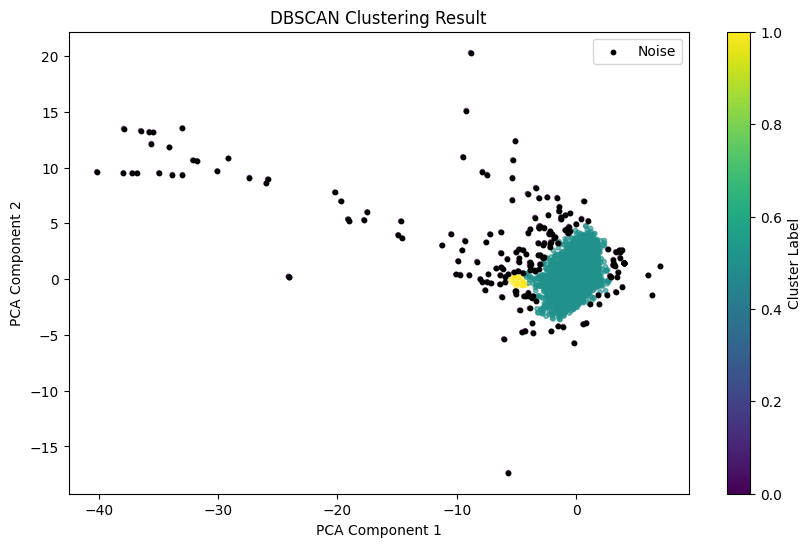

In [13]:
# DBSCAN 결과 시각화
plt.figure(figsize=(10, 6))

# 각 클러스터에 색상 할당 (-1은 노이즈로 검정색 표시)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis", s=10, alpha=0.6)

# 노이즈 데이터 강조 (클러스터 -1)
plt.scatter(X_pca[clusters == -1, 0], X_pca[clusters == -1, 1], 
            color="black", s=10, label="Noise")

# 그래프 설정
plt.title("DBSCAN Clustering Result")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.colorbar(label="Cluster Label")
plt.show()

## **2-7.결과 평가**

In [14]:
# 노이즈(-1)를 제외한 데이터로 실루엣 점수 계산
if len(set(clusters)) > 1:  # 클러스터가 2개 이상 있어야 계산 가능
    silhouette = silhouette_score(X_pca, clusters)
    print(f"Silhouette Score: {silhouette:.3f}")
else:
    print("Silhouette Score를 계산할 수 없습니다. (클러스터가 하나만 존재)")

Silhouette Score: 0.680


## **2-8.하이퍼파라미터 튜닝**

In [15]:
# 튜닝할 파라미터 범위 설정
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [5, 10, 15]

best_eps = None
best_min_samples = None
best_score = -1

# Grid Search 실행
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(X_pca)
        
        # 군집 수가 1개 초과일 때만 실루엣 점수 계산
        if len(set(clusters)) > 1:
            score = silhouette_score(X_pca, clusters)
            print(f"eps: {eps}, min_samples: {min_samples}, Silhouette Score: {score:.4f}")
            
            if score > best_score:
                best_eps = eps
                best_min_samples = min_samples
                best_score = score

print("\n최적 파라미터:")
print(f"Best eps: {best_eps}, Best min_samples: {best_min_samples}, Best Silhouette Score: {best_score:.4f}")

eps: 0.3, min_samples: 5, Silhouette Score: 0.3662
eps: 0.3, min_samples: 10, Silhouette Score: 0.7875
eps: 0.3, min_samples: 15, Silhouette Score: 0.4106
eps: 0.5, min_samples: 5, Silhouette Score: 0.6050
eps: 0.5, min_samples: 10, Silhouette Score: 0.6803
eps: 0.5, min_samples: 15, Silhouette Score: 0.8210
eps: 0.7, min_samples: 5, Silhouette Score: 0.7128
eps: 0.7, min_samples: 10, Silhouette Score: 0.6204
eps: 0.7, min_samples: 15, Silhouette Score: 0.8598
eps: 1.0, min_samples: 5, Silhouette Score: 0.9140
eps: 1.0, min_samples: 10, Silhouette Score: 0.8961
eps: 1.0, min_samples: 15, Silhouette Score: 0.8895

최적 파라미터:
Best eps: 1.0, Best min_samples: 5, Best Silhouette Score: 0.9140
